In [1]:
import importlib, GallenModel_v1, Landslidev2_Old, metrics, train
from typing import Optional
importlib.reload(GallenModel_v1)
importlib.reload(Landslidev2_Old)
importlib.reload(metrics)
importlib.reload(train)
from train import train_model_folds, train_model_folds_no_pga
from sklearn.metrics import confusion_matrix
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from data import dataframe_to_dataset
from imblearn.over_sampling import SMOTE
from imblearn import pipeline, under_sampling
import keras_tuner as kt
import sklearn
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import geopandas as gpd
import seaborn as sns
import pandas as pd
import contextily as cx
from data import NormalizationLayer
from metrics import plot_distribution, plot_susceptibility_map, plot_landslide_distribution
from GallenModel_v1 import  NewmarkActivation, DisplacementLayer, LandslideActivationLayer, CohesionLayer, InternalFrictionLayer  

In [2]:
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Training.gpkg')
df.drop(columns=['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction'], inplace=True)


In [3]:
df = df[df['Slope_mean'] >= 10]

In [4]:
columns = list(df.columns)
columns

['DN',
 'BD_mean',
 'Clay_mean',
 'Sand_mean',
 'Silt_mean',
 'NDVI_mean',
 'Est_mean',
 'Nrt_mean',
 'HorCurv_mean',
 'VertCurv_mean',
 'Slope_mean',
 'Elev_mean',
 'SoilThc_mean',
 'DistFlt_min',
 'LULC_majority',
 'TWI_mean',
 'PGA2_max',
 'PGA1_max',
 'Prc_mean',
 'Distrv_min',
 'distrd_min',
 'Soil Type',
 'BUK_mean',
 'landslide',
 'geometry']

In [5]:
df.dropna(subset=list(columns), inplace=True) #cleans the dataframe by removing null rows for all columns

In [6]:
df['Soil_Type'], _ = pd.factorize(df['Soil Type'])

In [7]:
cols_remove = ['DN', 'BD_mean', 'geometry', 'PGA2_max']
columns = [col for col in list(columns) if col not in cols_remove]
sampling_columns = [col for col in columns if col != 'landslide']
df[columns].head()

,Clay_mean,Sand_mean,Silt_mean,NDVI_mean,Est_mean,Nrt_mean,HorCurv_mean,VertCurv_mean,Slope_mean,Elev_mean,...,DistFlt_min,LULC_majority,TWI_mean,PGA1_max,Prc_mean,Distrv_min,distrd_min,Soil Type,BUK_mean,landslide
0,360.346280,340.681485,298.954953,0.665530,-0.836117,0.452621,0.000846,0.000460,26.916097,1920.972112,...,5593.218750,4.0,3.568248,0.225314,234.86586,2058.008545,2042.008789,0,10.484130,1
1,360.539905,341.044167,298.269993,0.515360,-0.642881,0.510736,0.000765,0.000549,30.162405,1948.885717,...,5535.918945,4.0,3.044424,0.225314,234.86586,2184.032959,2178.003662,0,10.480768,1
2,358.393445,340.194179,301.392539,0.475615,-0.388284,0.865236,-0.006900,0.002413,39.067499,1925.970839,...,5477.681641,4.0,3.626221,0.218405,234.86586,2250.000000,2256.014160,0,10.476539,1
3,366.153165,332.831341,301.015494,0.787397,0.274677,-0.559830,0.001612,-0.000406,40.482504,1398.288139,...,3778.954834,4.0,2.589944,0.202994,234.86586,1198.874512,1187.139404,0,10.921050,1
4,360.236476,338.236476,301.527048,0.790155,0.545462,-0.813949,0.003602,0.000275,42.364266,1487.782449,...,3846.296875,4.0,2.364016,0.202994,234.86586,1284.056030,1266.570190,0,10.907936,1


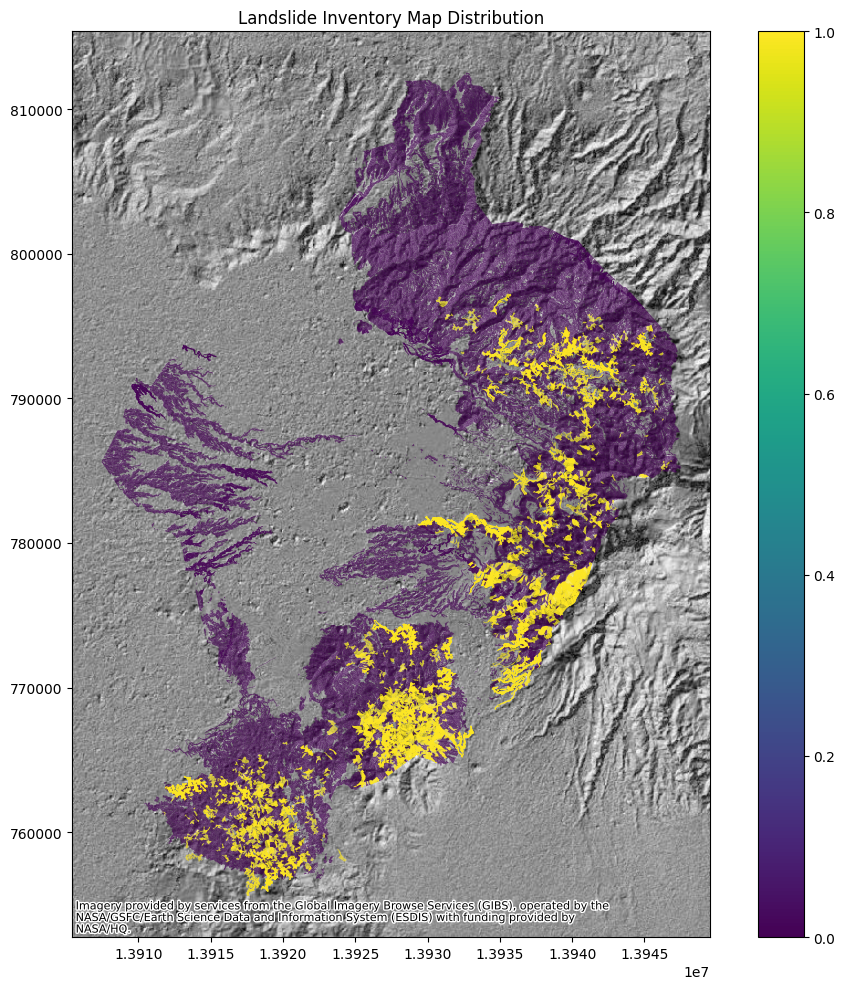

In [8]:
df_wm = df.to_crs(epsg=3857)
df_wm['landslide']

ax = df_wm.plot(column="landslide", legend=True, figsize=(10, 10), alpha=0.7)
ax.set_title("Landslide Inventory Map Distribution")
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
plt.tight_layout()
df_landslide = df[df['landslide'] == 1]

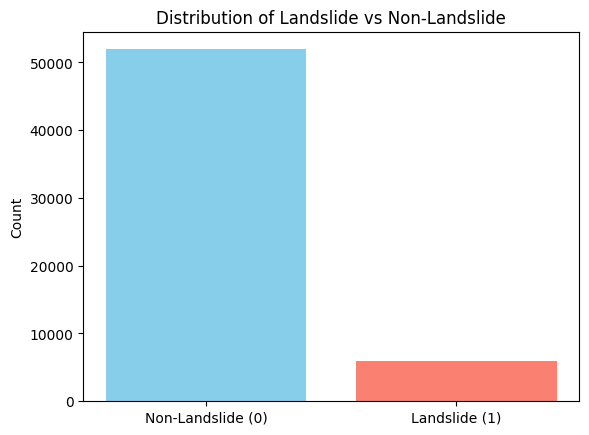

In [9]:
plot_landslide_distribution(df['landslide'].value_counts())

/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


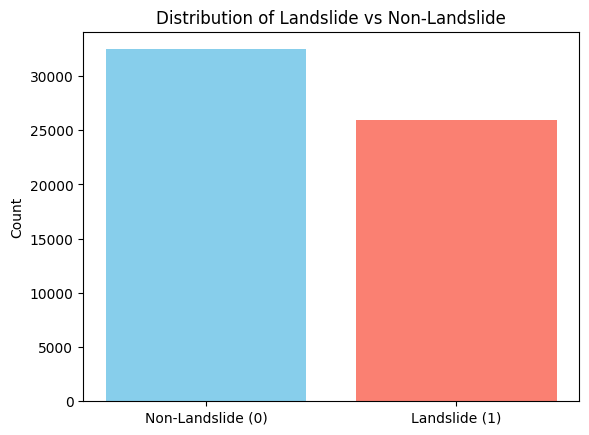

In [10]:
#Augment Dataset to address class imbalance.
#Undersampling and Oversampling techinique using SMOTE
X = df[sampling_columns]
# X = df.drop(columns=['VC_s', 'TARGET_F_1', 'Ls_count', 'Prc_s', 'Ls_AD', 'Shape_Leng', 'Ele_m', 'Sand_s', 'Nrt_s', 'Shape_Area', 'Join_Cou_1', 'geometry', 'Join_Count', 'TARGET_FID', 'Clay_s', 'Slp_s', 'Ls_Area', 'Ele_s', 'HC_s', 'id', 'Est_s', 'Shape_Le_1', 'PGV_Usgs', 'cat', 'NDVI_s', 'Bdod_s', 'GLG', 'Landslide'])
y = df['landslide']
over = SMOTE(sampling_strategy=0.5)
under = under_sampling.RandomUnderSampler(sampling_strategy=0.8)
steps = [('o', over), ('u', under)]
pl = pipeline.Pipeline(steps=steps)
X_resampled, y_resampled = pl.fit_resample(X, y)
plot_landslide_distribution(y_resampled.value_counts().sort_index())
X_resampled['landslide'] = y_resampled
sampled_df = X_resampled

In [11]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_dataset = dataframe_to_dataset(train_df[columns], batch_size=256)
test_dataset = dataframe_to_dataset(test_df[columns], batch_size=256, shuffle=False)
sampling_columns, columns

(['Clay_mean',
  'Sand_mean',
  'Silt_mean',
  'NDVI_mean',
  'Est_mean',
  'Nrt_mean',
  'HorCurv_mean',
  'VertCurv_mean',
  'Slope_mean',
  'Elev_mean',
  'SoilThc_mean',
  'DistFlt_min',
  'LULC_majority',
  'TWI_mean',
  'PGA1_max',
  'Prc_mean',
  'Distrv_min',
  'distrd_min',
  'Soil Type',
  'BUK_mean'],
 ['Clay_mean',
  'Sand_mean',
  'Silt_mean',
  'NDVI_mean',
  'Est_mean',
  'Nrt_mean',
  'HorCurv_mean',
  'VertCurv_mean',
  'Slope_mean',
  'Elev_mean',
  'SoilThc_mean',
  'DistFlt_min',
  'LULC_majority',
  'TWI_mean',
  'PGA1_max',
  'Prc_mean',
  'Distrv_min',
  'distrd_min',
  'Soil Type',
  'BUK_mean',
  'landslide'])

2026-01-23 14:07:46.462396: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-23 14:07:46.803352: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-23 14:07:47.465554: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-23 14:07:48.772119: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-23 14:07:51.378546: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


All inputs: [<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Clay_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Sand_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Silt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=NDVI_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Est_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Nrt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=HorCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=VertCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Slope_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Elev_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Soi

2026-01-23 14:10:33.033060: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


All inputs: [<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Clay_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Sand_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Silt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=NDVI_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Est_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Nrt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=HorCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=VertCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Slope_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Elev_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Soi

2026-01-23 14:18:03.533449: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


All inputs: [<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Clay_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Sand_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Silt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=NDVI_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Est_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Nrt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=HorCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=VertCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Slope_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Elev_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Soi

2026-01-23 14:31:46.329364: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


All inputs: [<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Clay_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Sand_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Silt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=NDVI_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Est_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Nrt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=HorCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=VertCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Slope_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Elev_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Soi

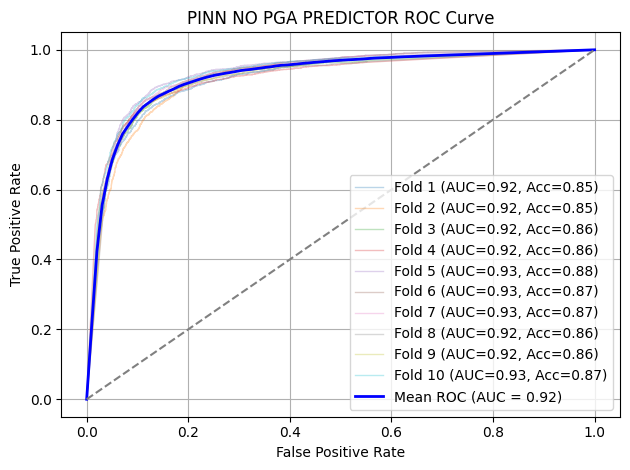

In [12]:
combinations  = [{"activation": "leaky", "optimizer": "adam", "leaky_alpha":0.2}]
for idx, combination in enumerate(combinations):
    losses = train_model_folds_no_pga(sampled_df, sampling_columns, columns, idx, combination['activation'], combination['optimizer'],pga_column="PGA1_max", path=f"/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v3-1FOS")

In [14]:
model = load_model("/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v3-1FOS/fold-10-model-0.keras")

In [15]:
dataset = dataframe_to_dataset(df[columns], shuffle=False)
susceptibility_prediction = model.predict(dataset)

1810/1810 ━━━━━━━━━━━━━━━━━━━━ 1s 647us/step


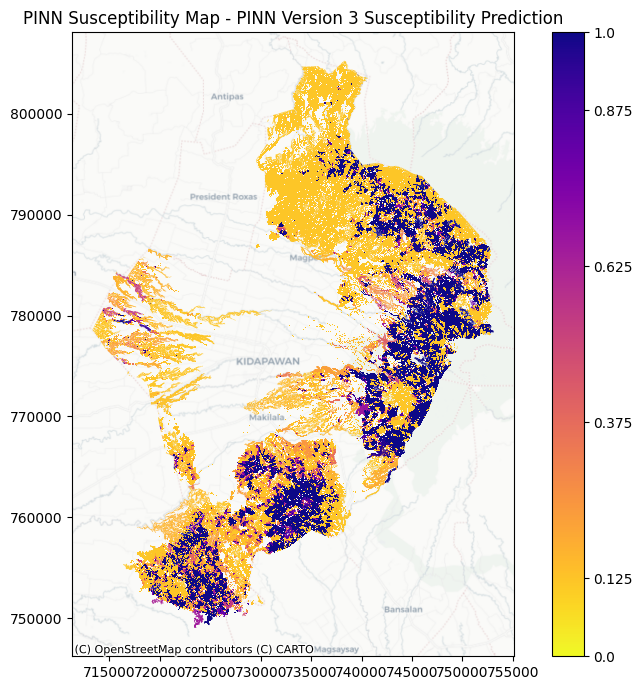

In [16]:
plot_susceptibility_map(df, susceptibility_prediction, "PINN Version 3 Susceptibility Prediction")

In [17]:
validation = gpd.read_file("~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation.gpkg")

In [18]:
validation.drop(columns=['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction'], inplace=True)

In [19]:
validation = validation[validation['Slope_mean'] >= 10]
validation.dropna(subset=list(columns), inplace=True) #cleans the dataframe by removing null rows for all columns
validation['Soil_Type'], _ = pd.factorize(validation['Soil Type'])

In [20]:
validation_dataset = dataframe_to_dataset(validation[columns], shuffle=False)

   1/7797 ━━━━━━━━━━━━━━━━━━━━ 1:40 13ms/step

7797/7797 ━━━━━━━━━━━━━━━━━━━━ 4s 562us/step


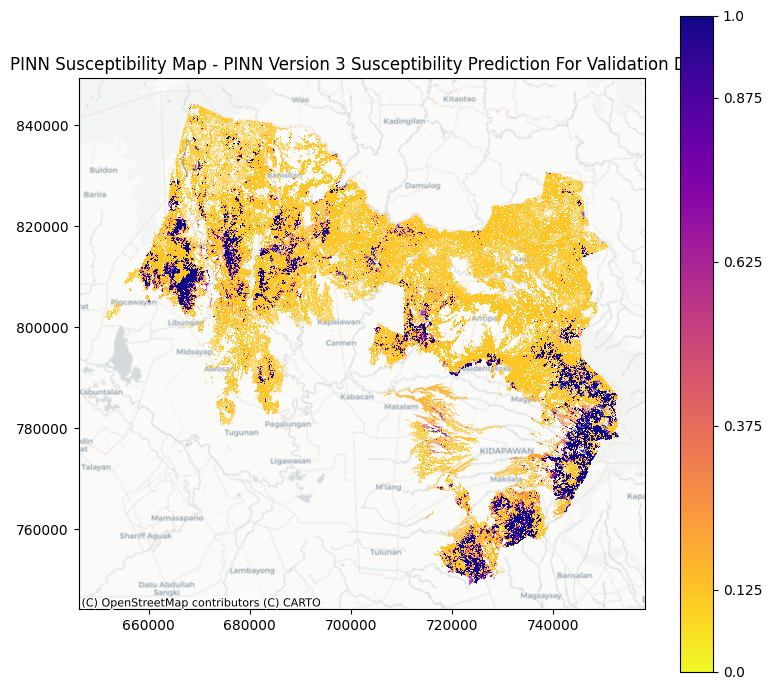

In [21]:
validation_susceptibility_prediction = model.predict(validation_dataset)
plot_susceptibility_map(validation, validation_susceptibility_prediction, "PINN Version 3 Susceptibility Prediction For Validation Data")

In [30]:
#Extract Geotechnical estimation of the model
df_wm = validation.to_crs(epsg=3857)
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("fos_layer").output)
predicted_fos = fos_model.predict(validation_dataset)
validation['FOS'] = predicted_fos



7797/7797 ━━━━━━━━━━━━━━━━━━━━ 4s 560us/step


In [31]:
#Extract Geotechnical estimation of the model
df_wm = validation.to_crs(epsg=3857)
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("cohesion_layer").output)
predicted_cohesion = fos_model.predict(validation_dataset)
validation['cohesion'] = predicted_cohesion



7797/7797 ━━━━━━━━━━━━━━━━━━━━ 4s 547us/step


In [32]:
#Extract Geotechnical estimation of the model
df_wm = validation.to_crs(epsg=3857)
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("internal_friction").output)
predicted_ifi = fos_model.predict(validation_dataset)
validation['ifi'] = predicted_ifi



7797/7797 ━━━━━━━━━━━━━━━━━━━━ 4s 557us/step


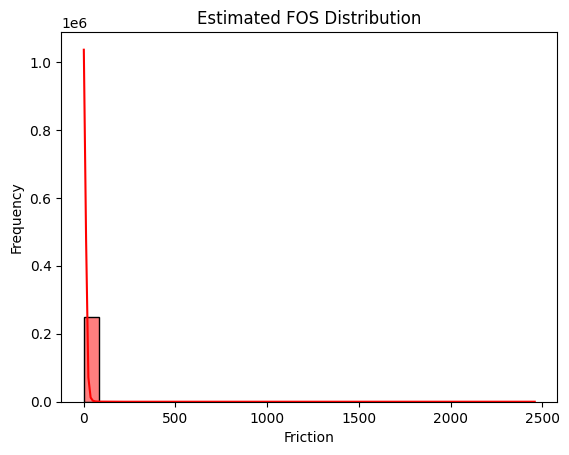

In [33]:
plot_distribution(df_wm, "Estimated FOS Distribution", "Friction", "Frequency", "FOS")
validation['FOS'] = predicted_cohesion

In [34]:
validation.columns

Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
       'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
       'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
       'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
       'Soil Type', 'BUK_mean', 'landslide', 'geometry', 'Soil_Type',
       'predicted_susceptibility', 'FOS', 'cohesion', 'ifi'],
      dtype='object')

In [35]:
validation.to_file("data/NorthCatabato_predicted-FOS.gpkg", layer="places", driver="GPKG")


In [ ]:
cohesion_input_names = [col for col in columns if col != 'landslide' and col != 'PGA1_max']

In [ ]:
input_tensors = {
    inp.name.split(":")[0]:inp for inp in model.input
}

cohesion_inputs = [input_tensors[name] for name in cohesion_input_names]

In [ ]:
cohesion = model.get_layer("cohesion_layer").output

cohesion = tf.keras.layers.Lambda(
    lambda x: tf.expand_dims(x, axis=-1),
    name="cohesion_expand"
)(cohesion)

geotech_model = tf.keras.Model(inputs=cohesion_inputs, outputs=cohesion)

cohesion = geotech_model.predict(validation_dataset)
cohesion.shape


7797/7797 ━━━━━━━━━━━━━━━━━━━━ 5s 669us/step


(249498, 1)

In [ ]:
import shap
def df_to_dict(df):
    return {
        col: df[col].values for col in columns if col != 'landslide'
    }
def df_to_input_list(df):
    return [df[col].values.reshape(-1, 1) for col in columns if col != 'landslide' and col != 'PGA1_max']

def df_to_shap_dict(df):
    inputs = {}

    for col in columns:
        if col == "landslide":
            continue 
    inputs[col] = df[col].values.reshape(-1, 1)
    return inputs
 
feature_names = [col for col in columns if col != 'landslide']

# def df_to_shap_input(df, pga_value):
#     inputs = {}
#     for col in feature_names:
#         inputs[col] = df[col].values.reshape(-1, 1)
    

sample_df = df.sample(100, random_state=42)

background_inputs = df_to_input_list(sample_df)
# background_inputs.append(sample_df['PGA1_max'].values.reshape(-1, 1))

test_inputs = df_to_input_list(df)
# test_inputs.append(df['PGA1_max'].values.reshape(-1, 1))

explainer = shap.GradientExplainer(model=geotech_model, data=background_inputs)

# Compute SHAP values for test data
print(f"Length of the model's input {len(geotech_model.input)}")
shap_values = explainer.shap_values(test_inputs)
X_test = df[feature_names].to_numpy()


/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Length of the model's input 19


Shap values: [[ 0.00421348 -0.00323435 -0.00289177 ...  0.0120968  -0.0003283
   0.00056684]
 [ 0.00951293 -0.00512913 -0.01757637 ...  0.01402367  0.00235778
  -0.00042024]
 [-0.0026459  -0.00177067 -0.00266128 ... -0.00649002  0.00356009
   0.00317964]
 ...
 [-0.07656282 -0.02927838  0.04897715 ...  0.03921212  0.03173295
   0.0171806 ]
 [-0.02871    -0.0693913   0.05199702 ... -0.00040682  0.02709605
   0.00085076]
 [-0.05720484  0.02392955  0.08058801 ...  0.0029385  -0.02604099
  -0.00608535]]
2 (57891, 19)
Feature names shape: 19


/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_6884/1341761866.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names)


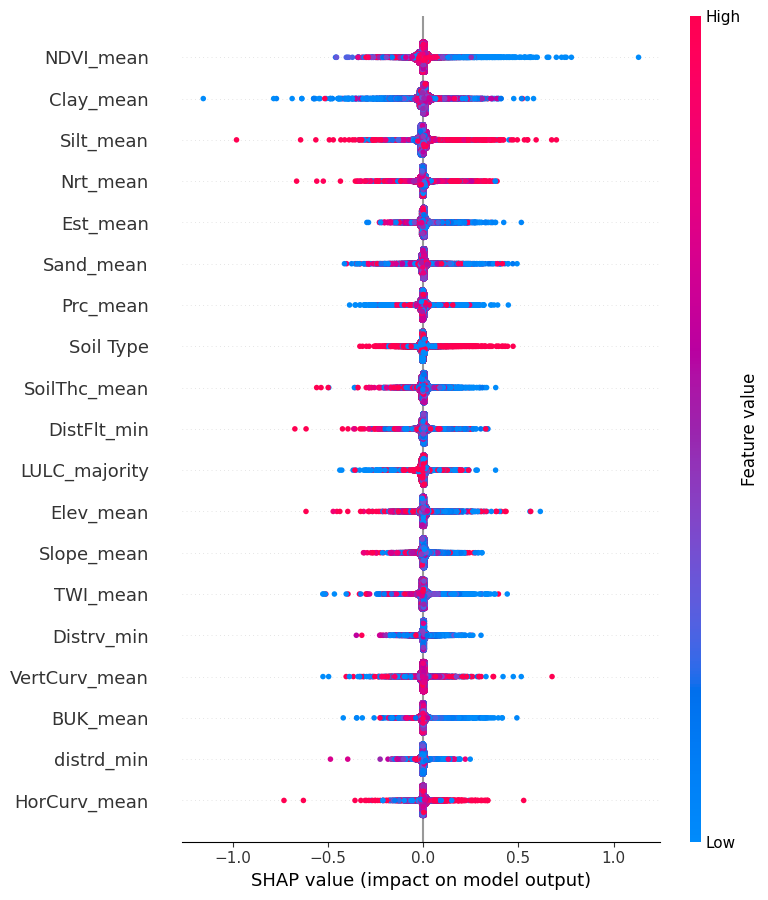

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot summary plot
shap_values = np.array(shap_values)
shap_values = np.squeeze(shap_values)   # removes extra (1,1) dims
shap_values = shap_values.T
print(f"Shap values: {shap_values}")
print(shap_values.ndim, shap_values.shape)
feature_names = [feature for feature in feature_names if feature != 'PGA1_max']
X_test = df[feature_names].to_numpy()
print(f"Feature names shape: {len(feature_names)}")
shap.summary_plot(shap_values, X_test, feature_names=feature_names)
plt.tight_layout()
plt.savefig(f'/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/figures/v2/historical/pinn-phase7-feature-importance.png', format="png")


In [ ]:
ifi = model.get_layer("internal_friction").output

ifi = tf.keras.layers.Lambda(
    lambda x: tf.expand_dims(x, axis=-1),
    name="internal_friction_expand"
)(ifi)

geotech_model_ifi = tf.keras.Model(inputs=cohesion_inputs, outputs=ifi)

ifi = geotech_model_ifi.predict(validation_dataset)
ifi.shape


7797/7797 ━━━━━━━━━━━━━━━━━━━━ 5s 651us/step


(249498, 1)

In [ ]:
explainer = shap.GradientExplainer(model=geotech_model_ifi, data=background_inputs)
print(f"Length of the model's input {len(geotech_model.input)}")

shap_values = explainer.shap_values(test_inputs)
X_test = df[feature_names].to_numpy()

Length of the model's input 19


Shap values: [[-0.0110861  -0.00381092  0.00283524 ...  0.021669    0.00775966
   0.00545522]
 [-0.01412855  0.00423319  0.02053185 ...  0.13453293  0.02726085
  -0.00494119]
 [-0.01290545  0.01603703  0.00901144 ...  0.11567679  0.03842949
  -0.01103707]
 ...
 [ 0.32080859  0.02982186 -0.02756059 ... -0.04802778 -0.03538045
   0.00807314]
 [ 0.2298362   0.03602243 -0.04255041 ... -0.01390508 -0.01238564
   0.00923594]
 [ 0.07401839  0.00697388 -0.03170836 ... -0.02614147 -0.03694103
   0.00659628]]
2 (57891, 19)
Feature names shape: 19


/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_6884/1341761866.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names)


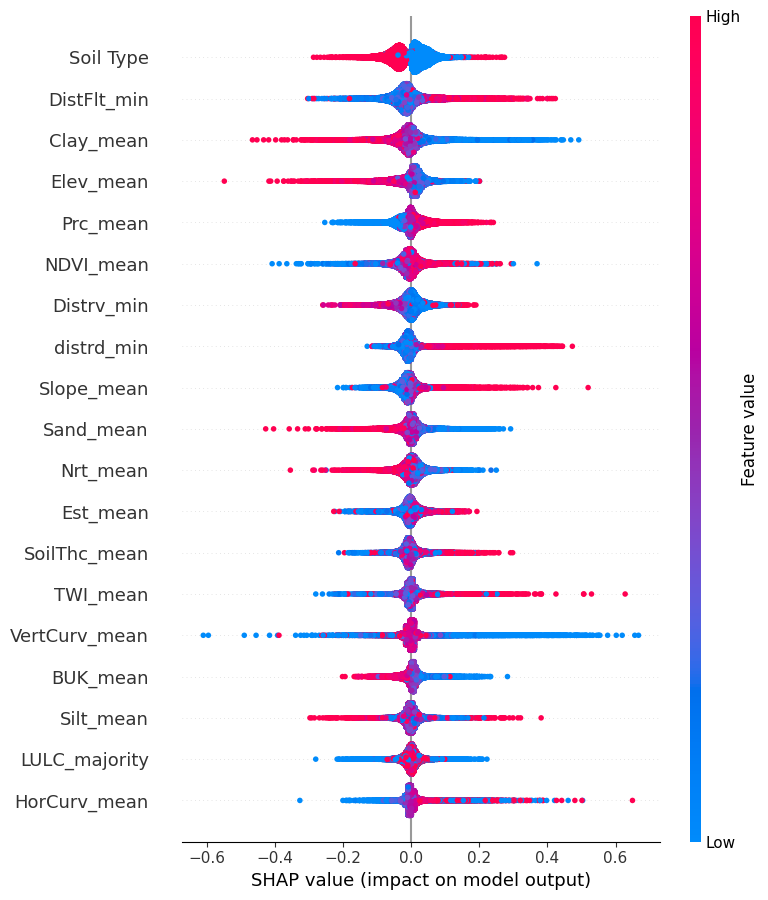

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot summary plot
shap_values = np.array(shap_values)
shap_values = np.squeeze(shap_values)   # removes extra (1,1) dims
shap_values = shap_values.T
print(f"Shap values: {shap_values}")
print(shap_values.ndim, shap_values.shape)
feature_names = [feature for feature in feature_names if feature != 'PGA1_max']
X_test = df[feature_names].to_numpy()
print(f"Feature names shape: {len(feature_names)}")
shap.summary_plot(shap_values, X_test, feature_names=feature_names)
plt.tight_layout()
plt.savefig(f'/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/figures/v2/historical/pinn-phase7-feature-importance.png', format="png")
